### Import

In [1]:
import sys
import os
sys.path.append(os.path.abspath('../'))

from environment.evaluation import *
from environment.data_loader import *
import random
from datetime import datetime

import itertools

import copy

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import seaborn as sns

### Get Config
Note that the below cell fetches all of the config data which is also used to train the models. This code will not run if you have not already completed a training simulation at some point with the same config parameters. If you have run the training already, you can set the `train_model` parameter in the `evaluation_congfig.yaml` file to `False` so that you can get the results without having to run the training again.

In [2]:
colors = {
    "DQN": 'darkorange',
    "REINFORCE": 'forestgreen',
    "ODT": 'blueviolet',
    "CMA": 'turquoise',
    "CMA-ES": 'turquoise'
}

season_colors = {
    "winter": 'blue',
    "spring": 'forestgreen',
    "summer": 'gold',
    "autumn": 'darkorange'
}

In [3]:
config_fname = 'config.yaml'

target_experiments = [4108, 4143] # Raw data to preprocess
exp_lists_preformatted = [
    '4000_4035.csv', # DQN
    '4036_4071.csv', # REINFORCE
    '4072_4107.csv', # CMA
    '4108_4143.csv', # ODT 1
] # Preprocessed data to use

file_path_for_processed_data = f'../../../../storage_1/metrics/formatted_experiment_data/part_6v2/'
base_path_metrics = f'../../../../storage_1/metrics/Exp_'
processed_csv_path = '../../../../storage_1/metrics/formatted_experiment_data/part_6v2/processed_for_plotting.csv'

# Load Data

In [4]:
# Use preprocessed data if available

if len(exp_lists_preformatted) > 0:
    dataframes_raw = []
    
    # Load and combine datasets
    for existing_set in exp_lists_preformatted:
        loaded_dataset = pd.read_csv(f"{file_path_for_processed_data}/{existing_set}")

        print(f"Loaded {existing_set} - {len(loaded_dataset)} rows")

        # Combine datasets
        dataframes_raw.append(loaded_dataset)

    dataframes = pd.concat(dataframes_raw, ignore_index=True)

Loaded 4000_4035.csv - 360000 rows
Loaded 4036_4071.csv - 360000 rows
Loaded 4072_4107.csv - 350000 rows
Loaded 4108_4143.csv - 134960 rows


In [5]:
# Load and process raw data

def load_from_json_with_error_handling(filepath):
    try:
        return read_csv_data(filepath)
    except json.JSONDecodeError as e:
        print(f"Error decoding JSON from {filepath}: {e.msg} at line {e.lineno}, column {e.colno}")
        return None  # Handle the error and return None or an empty object

if len(exp_lists_preformatted) == 0:
    rows = []

    # Preformat and save dataset
    for target_experiment in range(target_experiments[0], (target_experiments[1] + 1)):
        print(f"Processing Experiment {target_experiment}: {target_experiment - target_experiments[0] + 1}/{target_experiments[1] - target_experiments[0] + 1}")

        try:

            # Load the config file
            c = load_config_file(f'../experiments/Exp_{target_experiment}/{config_fname}')

            # Get the hyperparameters
            nn_c = c['nn_hyperparameters']
            federated_c = c['federated_learning_settings']
            algo_c = c['algorithm_settings']
            env_c = c['environment_settings']

            # Extract important config data
            agg_count = federated_c['aggregation_count']
            algorithm = algo_c['algorithm']
            seed = env_c['seed']

            # Get the data
            train_path = f'{base_path_metrics}{target_experiment}/train/metrics'
            episode_data_train = load_from_json_with_error_handling(f'{train_path}_agent_metrics.csv')

            episode_data_train['num_aggs'] = agg_count
            episode_data_train['algorithm'] = algorithm
            episode_data_train['seed'] = seed

            agg_episode_agent_cols = [
                'aggregation', 'episode', 'num_aggs', 'algorithm', 'seed', 'zone', 'agent_index'
            ]
            summed = episode_data_train.groupby(agg_episode_agent_cols)['reward'].sum().reset_index(name='ep_reward')

            group_cols_to_avg = ['aggregation', 'episode', 'num_aggs', 'algorithm', 'seed']
            averaged = summed.groupby(group_cols_to_avg)['ep_reward'].mean().reset_index(name='avg_episode_reward')

            for _, row in averaged.iterrows():
                rows.append({
                    'num_aggs': row['num_aggs'],
                    'algorithm': row['algorithm'],
                    'seed': row['seed'],
                    'episode': row['episode'],
                    'aggregation': row['aggregation'],
                    'training_reward': row['avg_episode_reward'],
                })
        except Exception as e:
            print(f"Error processing Experiment {target_experiment}: {e}")
            continue

    # Convert rows to DataFrame here
    dataframes = pd.DataFrame(rows)

    # Save the preprocessed data to a CSV file
    dataframes.to_csv(f'{file_path_for_processed_data}/{target_experiments[0]}_{target_experiments[1]}.csv', index=False)

# Display Results

## Reward

Loading processed data from ../../../../storage_1/metrics/formatted_experiment_data/part_6v2/processed_for_plotting.csv and plotting...


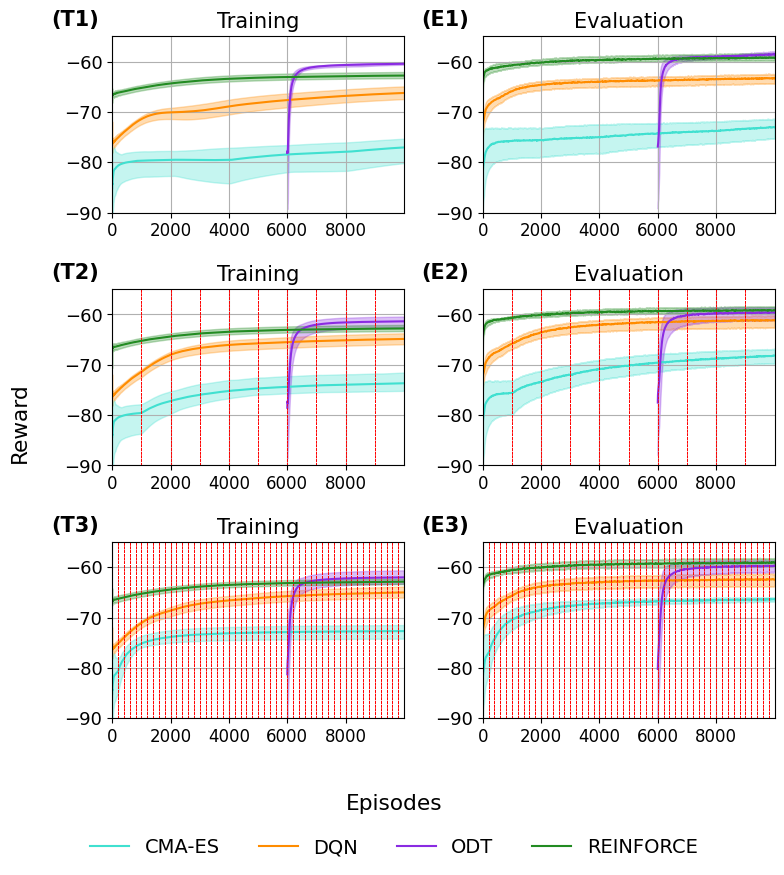

Plotting complete.


In [11]:
print(f"Loading processed data from {processed_csv_path} and plotting...")
processed_data = pd.read_csv(processed_csv_path)

processed_data.loc[processed_data['algorithm'] == 'ODT', 'absolute_episode'] += 6000

SHARED_Y_MIN = -90
SHARED_Y_MAX = -55

# Prepare aggregation levels and plot structure
agg_levels_sorted = sorted(processed_data['num_aggs'].unique())
algos_sorted = sorted(processed_data['algorithm'].unique())
num_agg_levels = len(agg_levels_sorted)
nrows, ncols = num_agg_levels, 2

# Set global font size
plt.rcParams.update({
    'font.size': 13,
    'axes.titlesize': 15,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 13,
    'legend.fontsize': 13,
    'figure.titlesize': 17
})

fig, axes = plt.subplots(nrows, ncols, figsize=(8, 0.6 + 2.7 * nrows), sharex=False, sharey='col')

if nrows == 1:
    axes = axes.reshape((1, 2))

subplot_labels = {}
for i in range(nrows):
    subplot_labels[(i, 0)] = f"(T{i + 1})"
    subplot_labels[(i, 1)] = f"(E{i + 1})"

algorithm_handles = {}
algorithm_labels = {}
algorithms_added_train = set()
algorithms_added_eval = set()

def subplots_visual(ax, title, label):
    ax.set_title(title)
    ax.text(
        -0.21, 1.15, label,
        transform=ax.transAxes,
        fontsize=15, fontweight='bold',
        va='top', ha='left'
    )

agg_interval_dict = {50: 200, 10: 1000, 1: 10000}

for row, agg_level in enumerate(agg_levels_sorted):
    agg_data = processed_data[processed_data['num_aggs'] == agg_level]

    # --- TRAINING REWARD PLOT (left column) ---
    ax_train = axes[row, 0]
    train_title = f"Training"
    subplots_visual(ax_train, train_title, subplot_labels[(row, 0)])

    # --- EVALUATION REWARD PLOT (right column) ---
    ax_eval = axes[row, 1]
    eval_title = f"Evaluation"
    subplots_visual(ax_eval, eval_title, subplot_labels[(row, 1)])

    min_x = agg_data['absolute_episode'].min()
    max_x = agg_data['absolute_episode'].max()

    for algo in algos_sorted:
        algo_plot_data = agg_data[agg_data['algorithm'] == algo]
        if algo_plot_data.empty:
            continue
            
        # Draw vertical red line at each aggregate episode
        aggregate_interval = agg_interval_dict[agg_level]
        for x in range(min_x + aggregate_interval, max_x + 1, aggregate_interval):
            ax_train.axvline(x=x, color='red', linestyle='--', linewidth=0.5)
            ax_eval.axvline(x=x, color='red', linestyle='--', linewidth=0.5)

        ax_train.fill_between(
            algo_plot_data['absolute_episode'], 
            algo_plot_data['min_tr'], algo_plot_data['max_tr'],
            color=colors[algo], alpha=0.3
        )
        line_train, = ax_train.plot(
            algo_plot_data['absolute_episode'], algo_plot_data['mean_tr'],
            color=colors[algo], label=algo
        )
        if algo not in algorithms_added_train:
            algorithm_handles[algo] = line_train
            algorithm_labels[algo] = ('CMA-ES' if algo == 'CMA' else algo)
            algorithms_added_train.add(algo)

        ax_eval.fill_between(
            algo_plot_data['absolute_episode'], 
            algo_plot_data['min_ev'], algo_plot_data['max_ev'],
            color=colors[algo], alpha=0.3
        )
        line_eval, = ax_eval.plot(
            algo_plot_data['absolute_episode'], algo_plot_data['mean_ev'],
            color=colors[algo], label=algo
        )
        if algo not in algorithms_added_eval:
            algorithm_handles[f'eval_{algo}'] = line_eval
            algorithm_labels[f'eval_{algo}'] = ('CMA-ES' if algo == 'CMA' else algo)
            algorithms_added_eval.add(algo)

    ax_train.grid(True)
    ax_train.set_xlim([min_x, max_x])
    ax_eval.grid(True)
    ax_eval.set_xlim([min_x, max_x])

for ax in axes.flat: 
    ax.set_ylim([SHARED_Y_MIN, SHARED_Y_MAX])

fig.supylabel('Reward')
fig.supxlabel('Episodes', y=0.05)

unique_labels = []
unique_lines = []
legend_algos = sorted(set(algorithm_labels.values()), key=str.lower)
for algo in legend_algos:
    found = False
    for handle_algo, label in algorithm_labels.items():
        if label == algo:
            unique_labels.append(label)
            unique_lines.append(algorithm_handles[handle_algo])
            found = True
            break
    if not found:
        continue

fig.legend(unique_lines, unique_labels,
            loc='lower center',
            ncol=len(unique_labels),
            bbox_to_anchor=(0.5, -0.02),
            frameon=False,
            fontsize=14)

plt.tight_layout(rect=[0, 0.06, 1, 1])
fig.savefig('./figures/agg_level_train_eval_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print("Plotting complete.")

## Training Duration Metrics